In [1]:
from gammaraytoys.detectors import ToyCodedMaskDetector3D
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from astropy.coordinates import Angle, SkyCoord, UnitSphericalRepresentation
from astropy.units import Quantity
from scipy.stats import poisson, norm, chi2
from histpy import Histogram, Axis

from gammaraytoys import poisson_binned_log_likelihood, unbinned_log_likelihood, richardson_lucy
from gammaraytoys.analysis import FastNormFit

from scipy.stats import norm, chi2

import cProfile

%load_ext line_profiler

In [2]:
det = ToyCodedMaskDetector3D.create_random_mask(mask_size = 40 * u.cm, 
                                                mask_npix = 130, 
                                                mask_separation = 100 * u.cm, 
                                                open_fraction = .5, 
                                                detector_size = 22 * u.cm, 
                                                detector_npix = 440, 
                                                detector_efficiency = 0.65)

In [4]:
det.compute_response([-2,2]*u.deg, [-2,2]*u.deg)

100%|██████████| 115/115 [14:15<00:00,  7.43s/it]


In [5]:
det.write('gale_like_v0.1_2deg.h5')

In [2]:
det = ToyCodedMaskDetector3D.open('gale_like_v0.1.h5')

In [4]:
coord = SkyCoord(l = 0*u.arcmin, b = 0*u.arcmin, frame = 'galactic')

flux = 1/u.cm/u.cm/u.s
duration = 1*u.s

(<Axes: xlabel='lon [deg]', ylabel='lat [deg]'>,
 <matplotlib.collections.QuadMesh at 0x136362f90>)

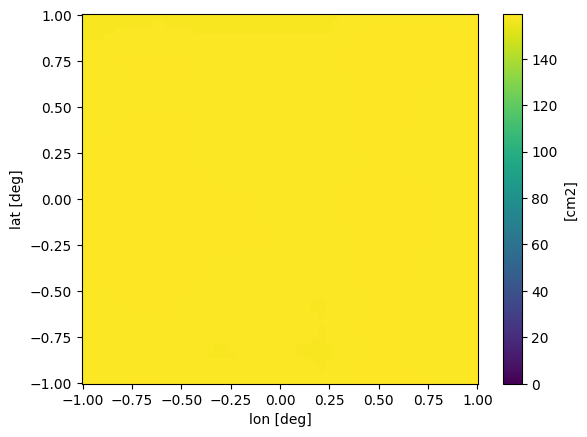

In [11]:
det.response.project('lon','lat').plot(vmin = 0)

158.28761980442704


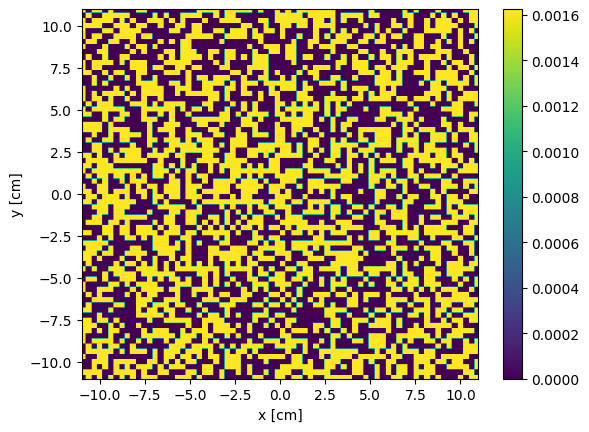

In [8]:
shadowgram = det.point_source_response(flux, duration, coord)
print(np.sum(shadowgram))
shadowgram.plot();

55.82821648701357


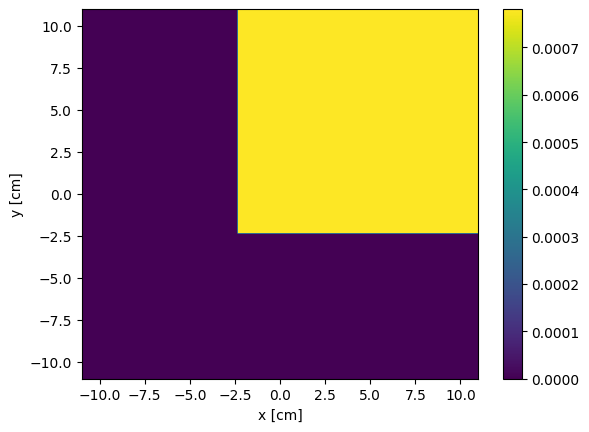

In [6]:
shadowgram_nonimg = det.point_source_response(flux, duration, coord, imaging = False)
ax,_= shadowgram_nonimg.plot()
print(np.sum(shadowgram_nonimg))

In [34]:
# Atm Gehrels 1985
5.88e-2*(.5/1)**-1.75 * (1/u.cm/u.cm/u.s/u.sr/u.MeV) * (.511 *u.MeV)

<Quantity 0.10106499 1 / (s sr cm2)>

In [55]:
# EG Gruber 1999 https://iopscience.iop.org/article/10.1086/307450/pdf
(0.0259 * (511/60)**-5.5 + 0.504 * (511/60)**-1.58 + 0.0288 * (511/60)**-1.05)*(u.keV/u.cm/u.cm/u.s/u.sr/u.keV)

<Quantity 0.02012294 1 / (s sr cm2)>

In [48]:
2*np.pi/(1-np.cos(25*u.deg))

<Quantity 67.06197995>

In [57]:
.02/.51

0.0392156862745098

In [58]:
0.02  * (u.keV/u.cm/u.cm/u.s/u.sr/u.keV) * (2*.02 * 511 * u.keV) / (511 * u.keV)

<Quantity 0.0008 1 / (s sr cm2)>

In [54]:
511 * 7e-3 * (1/(u.sr*2*np.pi/(1-np.cos(25*u.deg)))) / u.keV / u.s / (16*u.cm*u.cm)

<Quantity 0.00333367 1 / (keV s sr cm2)>

In [9]:
(100*u.arcmin).to(u.deg)

<Quantity 1.66666667 deg>

In [4]:
flux = 1/u.cm/u.cm/u.s
coord = UnitSphericalRepresentation(lon = 0*u.deg, lat = 0*u.deg)

extension = 0*u.deg
model = det.gaussian_model(flux, coord, extension, extension)
model.plot()

wider_bulge_model = det.gaussian_model(7.3e-4/u.cm/u.cm/u.s, coord, 20*u.deg, 20*u.deg)
wider_bulge_model.plot()

narrow_bulge_model = det.gaussian_model(2.8e-4/u.cm/u.cm/u.s, coord, 6*u.deg, 6*u.deg)
narrow_bulge_model.plot()

bkg_model = det.isotropic_diffuse_model((0.02 + 0.095)/u.cm/u.cm/u.s/u.sr)
bkg_model.plot()

bkg_all_model = narrow_bulge_model+wider_bulge_model+bkg_model

bkg_all_model.plot()

> /Users/imartin5/software/gammaraytoys/gammaraytoys/detectors/coded_mask/threeD/coded_mask_3d.py(431)gaussian_model()
    429         # Set containment based on sorted probability
    430         breakpoint()
--> 431         np.sort(pdf_int)
    432 
    433         # Multiply by flux



ipdb>  exit


In [80]:
det.response.nbins

array([ 81,  81, 440, 440])

In [82]:
(compact_model.contents != 0)[:,:,None,None].shape

(976, 976, 1, 1)

In [85]:
det.sky_axes['lon'].find_bin(det.response.axes['lon'].edges[0])
det.sky_axes['lat'].find_bin(det.response.axes['lat'].edges[0])

np.int64(448)

In [14]:
lon_bins, lat_bins = np.where(compact_model.contents != 0)
lon_bin0 = det.sky_axes['lon'].find_bin(det.response.axes['lon'].edges[0])
lat_bin0 = det.sky_axes['lat'].find_bin(det.response.axes['lat'].edges[0])
lon_bins_rsp = lon_bins - lon_bin0
lat_bins_rsp = lat_bins - lat_bin0

In [15]:
det.response.axes['lon'].find_bin(compact_model.axes['lon'].edges[lon_bins])

array([ 5,  5,  5, ..., 75, 75, 75])

In [207]:
det.response[lon_bins_rsp, lat_bins_rsp].shape

(9, 440, 440)

In [213]:
compact_model[lon_bins, lat_bins]

<Quantity [2.28693889e-06, 1.07312950e-05, 2.08148860e-06, 1.07312950e-05,
           5.03558236e-05, 9.76723438e-06, 2.08148860e-06, 9.76723438e-06,
           1.89449522e-06] 1 / (s cm2)>

In [215]:
np.dot(np.transpose(det.response[lon_bins_rsp, lat_bins_rsp], [1,2,0]), 
       compact_model[lon_bins, lat_bins])

Unit("1 / s")

In [8]:
compact_model.nbins

array([976, 976])

In [29]:
%%time

flux = 1/u.cm/u.cm/u.s
coord = UnitSphericalRepresentation(lon = 0*u.deg, lat = 0*u.deg)
extension = 10*u.arcmin
compact_model = det.gaussian_model(1e-4/u.cm/u.cm/u.s, coord, extension, extension)
compact_signal = det.convolve_model(compact_model, 1*u.s)

100%|██████████| 651/651 [00:01<00:00, 421.59it/s]

CPU times: user 4 s, sys: 178 ms, total: 4.18 s
Wall time: 4.26 s


(<Axes: xlabel='x [cm]', ylabel='y [cm]'>,
 <matplotlib.collections.QuadMesh at 0x13730a990>)

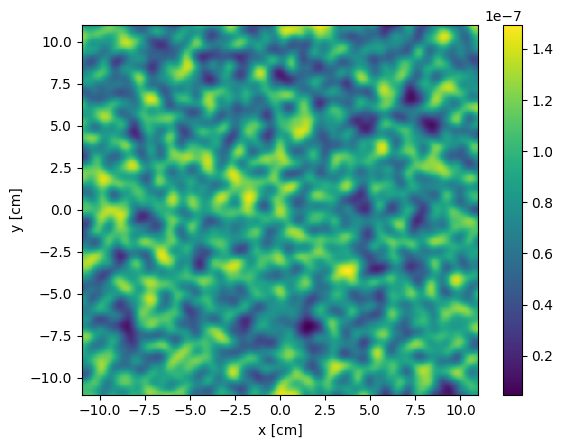

In [30]:
compact_signal.plot()

<Quantity 9.90021485e-05 1 / (s cm2)>

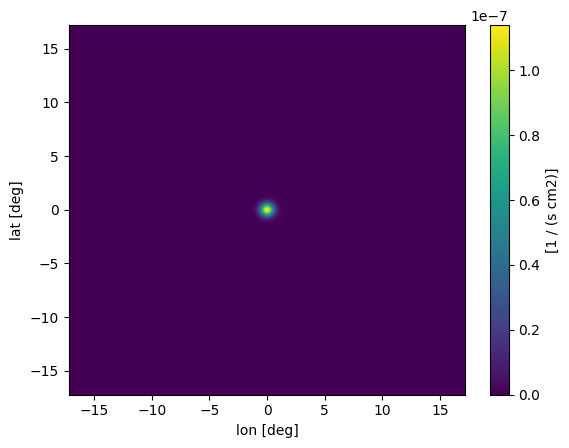

In [6]:
compact_model.plot()
np.sum(compact_model)

In [6]:
det.effective_area(coord)*1*u.s*(1e-4/u.cm/u.cm/u.s)

<Quantity 0.01584851>

In [13]:
duration = 2*u.year
signal = det.convolve_model(model, duration)
bkg = det.convolve_model(bkg_all_model.rebin(20,20), duration, imaging = False)

100%|██████████| 2304/2304 [00:09<00:00, 248.13it/s]


In [7]:
(1e7*u.s).to(u.yr)

<Quantity 0.31688088 yr>

In [9]:
4e-2*(1/u.s/u.keV)*(40*u.keV)*(150/16)

<Quantity 15. 1 / s>

(<Axes: xlabel='x [cm]', ylabel='y [cm]'>,
 <matplotlib.collections.QuadMesh at 0x1366c6a10>)

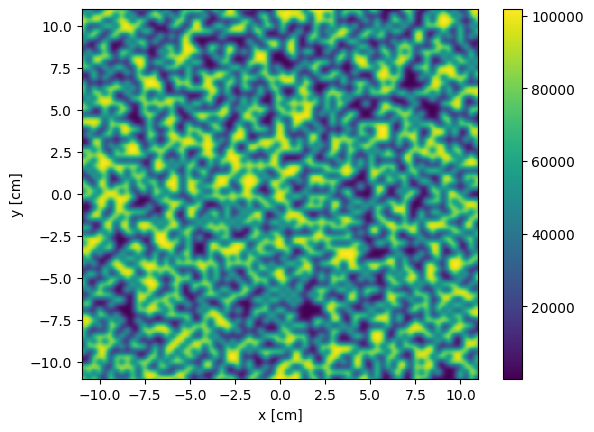

In [14]:
signal.plot()

In [42]:
from scipy.stats import multivariate_normal, norm

max_sigma = 3


print(norm.cdf(3) - norm.cdf(-3))

dist = multivariate_normal(mean = [0,0], cov = [[1**2,0],[0,2**2]])

dist.cdf([3,2*3]) - dist.cdf([-3,-2*3])

0.9973002039367398


np.float64(0.9973002039367398)

In [48]:
-norm.ppf(1-.99)

np.float64(2.3263478740408408)

(<Axes: xlabel='x [cm]', ylabel='y [cm]'>,
 <matplotlib.collections.QuadMesh at 0x1362ecc10>)

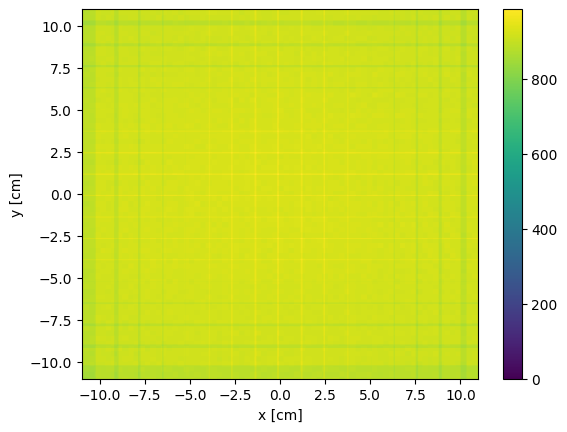

In [15]:
bkg.plot(vmin = 0)

In [18]:
signal_factor = .5e-4
tot_signal = np.sum(signal_factor*signal)
tot_bkg = np.sum(bkg)
tot_signal/np.sqrt(tot_bkg)

np.float64(37.440091204184974)

In [17]:
(tot_bkg/duration).to(u.Hz)

<Quantity 2.80656441 Hz>

In [ ]:
extension = 0*u.deg
model = det.gaussian_model(flux, coord, extension, extension)
model.plot()
bkg = det.uniform_bkg(np.sum(bkg)/duration, duration)

In [ ]:
norm.

In [14]:
flux = 5e-5/u.cm/u.cm/u.s
coord = UnitSphericalRepresentation(lon = 0*u.deg, lat = 0*u.deg)
duration = 1*u.year

bkg = det.uniform_bkg(15*u.Hz, duration)

fnf = FastNormFit()

def get_ts(bkg, signal):

    data = bkg + signal 

    # Float bkg
    ts_0,_,_,_ = fnf.solve(data, bkg, bkg)
    
    ts_1 = fnf.ts(data, bkg, signal, norm = 1)

    ts = ts_1 - ts_0
    
    return ts

def ts_to_signif(ts, ndof):
    
    signif = norm.isf(chi2.sf(ts, df = ndof))
    
    return signif

def signif_vs_extension(extension):

    signal_model = det.gaussian_model(flux, coord, extension, extension)
    
    signal = det.convolve_model(signal_model, duration)

    return get_ts(bkg, signal)

In [12]:
def compute_sensitivity(extension, flux_bounds, ndof, signif_thresh = 5, signif_thresh_tol = 0.01, max_iter = 100):

    # Get unit flux signal
    signal_model = det.gaussian_model(1*flux_bounds.unit, coord, extension, extension)
    
    signal0 = det.convolve_model(signal_model, duration)

    # Init bisections
    norm = flux_bounds.value

    signif = [ts_to_signif(get_ts(bkg, signal0*norm[0]), ndof), 
              ts_to_signif(get_ts(bkg, signal0*norm[1]), ndof)]

    if signif[0] > signif_thresh:
        raise InputError("Lower bound above significance threshold")
    if signif[1] < signif_thresh:
        raise InputError("Upper bound below significance threshold")
    
    iter = 0

    # Run bisections
    while iter < max_iter:

        # Mid point
        norm_mid = np.mean(norm)
        signif_mid = ts_to_signif(get_ts(bkg, signal0*norm_mid), ndof)

        # Check condition
        if np.abs(signif_mid - signif_thresh) < signif_thresh_tol:
            return norm_mid * flux_bounds.unit

        # Update bounds
        if np.sign(signif_mid - signif_thresh) == np.sign(signif[0] - signif_thresh):
            norm[0] = norm_mid
            signif[0] = signif_mid
        else:
            norm[1]= norm_mid
            signif[1] = signif_mid
        
        iter += 1

    return np.nan

In [15]:
compute_sensitivity(1*u.arcmin, [1e-6, 1e-2]/u.cm/u.cm/u.s, ndof = 4)

100%|██████████| 9/9 [00:00<00:00, 91.44it/s]


<Quantity 3.02939453e-05 1 / (s cm2)>

In [112]:
ts_vs_extension(1*u.arcmin)

100%|██████████| 9/9 [00:00<00:00, 360.52it/s]


np.float64(98.1451141597756)

In [36]:
np.sqrt(116.38)

np.float64(10.787956247593888)

In [21]:
extension_list = [0, 1, 2, 4, 8, 16, 32]*u.arcmin
sensi = [compute_sensitivity(e, [1e-6, 1e-2]/u.cm/u.cm/u.s, ndof = 4) for e in extension_list]

100%|██████████| 6623/6623 [00:22<00:00, 288.42it/s]


In [74]:
extension_list = [0, 1, 2, 4, 8, 16, 32]*u.arcmin
ts = [ts_vs_extension(e) for e in extension_list]

100%|██████████| 6623/6623 [01:57<00:00, 56.15it/s] 


In [72]:
ts

[np.float64(4957202493.486584),
 np.float64(4096999785.450197),
 np.float64(3149808542.9103794),
 np.float64(1687229668.8728657),
 np.float64(571059942.7114563),
 np.float64(165119181.8506279),
 np.float64(49304376.04868698)]

In [102]:
new_extension.insert(0, extension)

<Quantity [ 0. ,  7.5, 15. , 30. ] arcmin>

In [100]:
extension

<Quantity [ 0. ,  7.5, 15. ] arcmin>

In [103]:
new_extension = [30]*u.arcmin
ts += [ts_vs_extension(e) for e in new_extension]
extension = new_extension.insert(0, extension)

100%|██████████| 20449/20449 [24:14<00:00, 14.06it/s] 


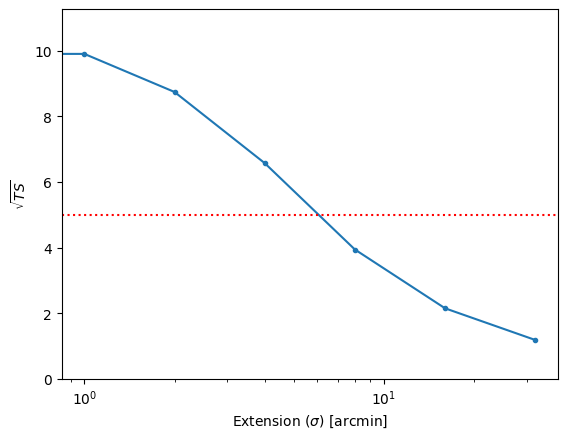

In [110]:
fig,ax = plt.subplots()

ax.plot(extension_list.to_value(u.arcmin), np.sqrt(ts), marker = '.')

ax.set_xlabel("Extension ($\sigma$) [arcmin]")
ax.set_ylabel("$\sqrt{TS}$")

ax.axhline(5, color = 'red', ls = ':')

ax.set_ylim(0, None)
ax.set_xscale('log')

In [148]:
sensi

[<Quantity 2.31707106e-05 1 / (s cm2)>,
 <Quantity 2.52304411e-05 1 / (s cm2)>,
 <Quantity 2.85775032e-05 1 / (s cm2)>,
 <Quantity 3.80179348e-05 1 / (s cm2)>,
 <Quantity 6.34022064e-05 1 / (s cm2)>,
 <Quantity 0.00011631 1 / (s cm2)>,
 <Quantity 0.00021117 1 / (s cm2)>]

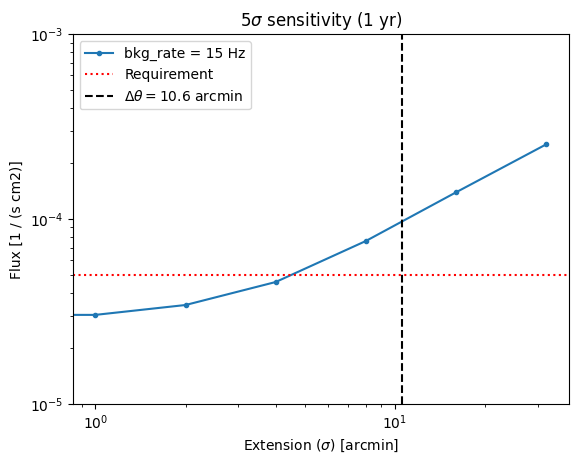

In [22]:
fig,ax = plt.subplots()

y_unit = u.Unit('cm^-2 s^-1')
x_unit = u.arcmin
ax.plot(extension_list.to_value(x_unit), u.Quantity(sensi).to_value(y_unit), marker = '.', 
        label = 'bkg_rate = 15 Hz')

ax.set_xlabel("Extension ($\sigma$) [arcmin]")
ax.set_ylabel(f"Flux [{y_unit}]")

ax.axhline((.5e-4/u.cm/u.cm/u.s).to_value(y_unit), color = 'red', ls = ':', label = 'Requirement')

ax.axvline(det.angular_resolution.to_value(x_unit), 
           color = 'black', ls = '--', label = f'$\Delta \\theta = ${det.angular_resolution.to(x_unit):.1f}')

ax.set_ylim(1e-5,1e-3)
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_title('$5\sigma$ sensitivity (1 yr)')

ax.legend()

In [106]:
(5*.5*np.sqrt((2*u.Hz * duration)) / duration / (60*u.cm*u.cm)).to(1/u.cm**2/u.s)

<Quantity 1.04894272e-05 1 / (s cm2)>

In [9]:
norm.isf(chi2.sf(10000, df = 10))

np.float64(inf)

In [67]:
np.sqrt(ts)

np.float64(41.62960149373872)

In [23]:
2*log_like_null

np.float64(2068320731.5992284)

In [60]:


log_like = poisson_binned_log_likelihood(data.contents, data.contents)
log_like_null = poisson_binned_log_likelihood(data.contents, (1+null_excess_norm) * bkg.contents)
ts = 2*(log_like - log_like_null)

norm.isf(chi2.sf(ts, df = 2)) # df: source norm, bkg norm

np.float64(inf)

In [27]:
ts

np.float64(263.7255039215088)

(<Axes: xlabel='x [cm]', ylabel='y [cm]'>,
 <matplotlib.collections.QuadMesh at 0x129d06b10>)

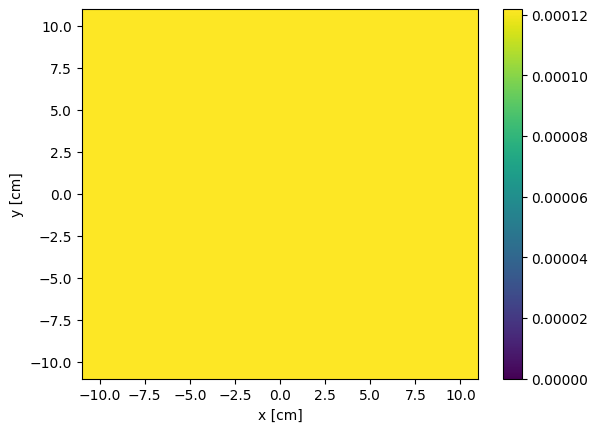

In [24]:
bkg_uniform.plot(vmin = 0)

(<Axes: xlabel='x [cm]', ylabel='y [cm]'>,
 <matplotlib.collections.QuadMesh at 0x128c50890>)

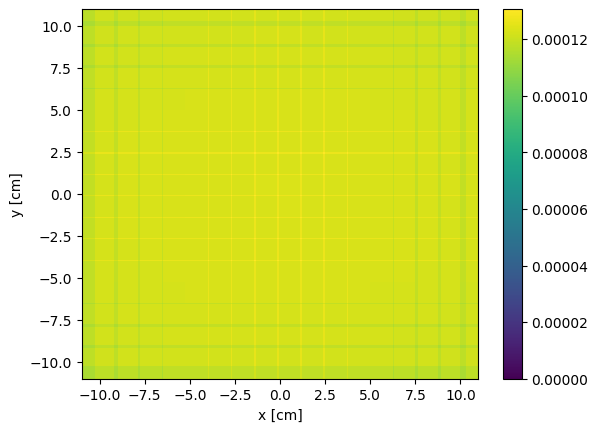

In [19]:
bkg.plot(vmin = 0)

In [17]:
expectation.contents.flatten()

array([0.00015884, 0.00162476, 0.00162476, ..., 0.00028382, 0.00162476,
       0.00162476])

In [13]:
poisson_binned_log_likelihood(expectation.contents.flatten(), )

Signature: poisson_binned_log_likelihood(data, expectation)
Docstring: <no docstring>
File:      ~/software/gammaraytoys/gammaraytoys/analysis/likelihoods.py
Type:      function

In [ ]:
expectation

(<Axes: xlabel='x [cm]', ylabel='y [cm]'>,
 <matplotlib.collections.QuadMesh at 0x132ccc6d0>)

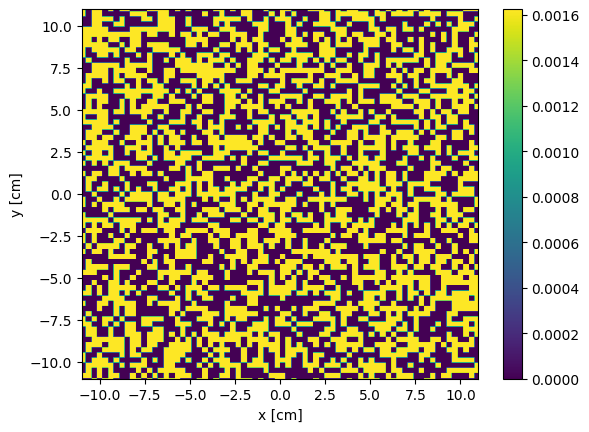

In [12]:
expectation.plot()

(<Axes: xlabel='lon [deg]', ylabel='lat [deg]'>,
 <matplotlib.collections.QuadMesh at 0x1315a7990>)

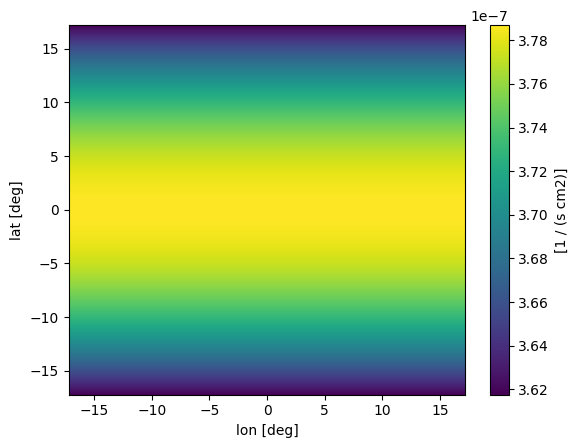

In [6]:
det.isotropic_diffuse_model(1/u.cm/u.cm/u.s/u.sr).plot()

In [12]:
(2*u.deg * np.sin(59*u.deg) * u.rad / u.sr).to('')

<Quantity 0.02992078>

In [5]:
det.uniform_bkg(1/u.s, 1*u.s)

np.float64(1.0000000000000002)

(<Axes: xlabel='x [cm]', ylabel='y [cm]'>,
 <matplotlib.collections.QuadMesh at 0x133fe16d0>)

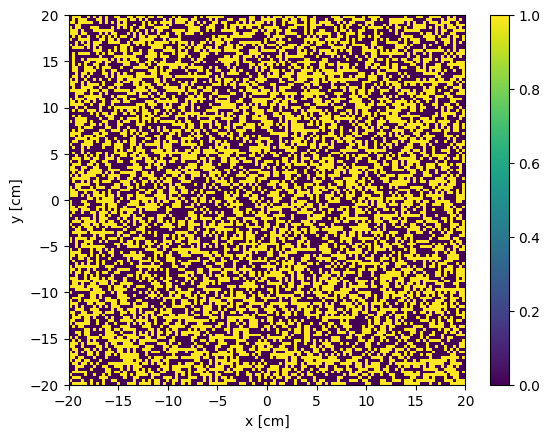

In [3]:
det.mask.plot()

In [3]:
coord = SkyCoord(l = 0.1*u.deg, b = 1*u.deg, frame = 'galactic')

flux = 1/u.cm/u.cm/u.s
duration = 1*u.s

shadowgram = det.point_source_response(flux, duration, coord)

shadowgram_nonimg = det.point_source_nonimg_response(flux, duration, coord)

shadowgram.plot()
shadowgram_nonimg.plot()

TypeError: only dimensionless scalar quantities can be converted to Python scalars

In [5]:
det.sky_axes.nbins

array([976, 976])

In [3]:
flux = 1/u.cm/u.cm/u.s
coord = UnitSphericalRepresentation(lon = 0*u.deg, lat = 0*u.deg)
width_lon = 10*det.angular_resolution
width_lat = 10*det.angular_resolution

model = det.gaussian_model(flux, coord, width_lon, width_lat)

flux = 1e-2/u.cm/u.cm/u.s
coord = UnitSphericalRepresentation(lon = 0*u.deg, lat = 0*u.deg)
width_lon = 1*det.angular_resolution
width_lat = 1*det.angular_resolution

model += det.gaussian_model(flux, coord, width_lon, width_lat)

flux = 1e-2/u.cm/u.cm/u.s
coord = UnitSphericalRepresentation(lon = 0*u.deg, lat = 4*u.deg)
width_lon = 1*det.angular_resolution
width_lat = 1*det.angular_resolution

model += det.gaussian_model(flux, coord, width_lon, width_lat)

UnitConversionError: Specify units

In [38]:
np.sum(model)

<Quantity 1.0047432 1 / (s cm2)>

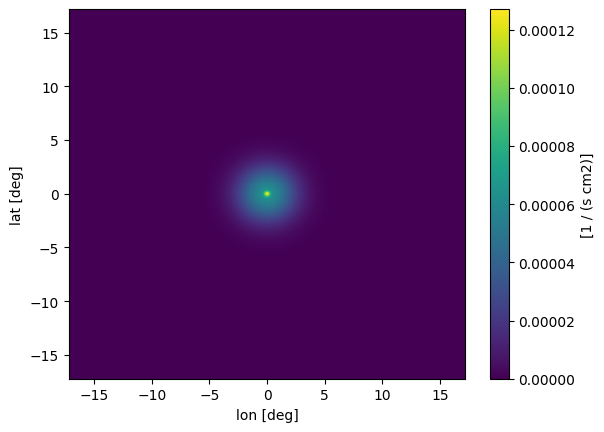

In [39]:
ax, _  = model.plot()

# ax.set_xlim(-1,1)
# ax.set_ylim(-1,1)

In [ ]:
model.plot()

In [ ]:
lon_unit,lat_unit

In [ ]:
det.response.contents.value.size*8*1e4/1e9

In [ ]:
import sys

sys.getsizeof(det.response.contents.value)

In [ ]:
50*1e4/3600

In [ ]:
det.response.project(0,1).plot()

In [ ]:
det.response.slice[0,1].project(2,3).plot()

In [ ]:
(np.prod(det.sky_axes.nbins) * np.prod(det.detector_axes.nbins)) * 8 / 1e9

In [ ]:
np.sum(shadowgram)

In [ ]:
cProfile.run('det.point_source_response(1/u.cm/u.cm/u.s, 1*u.s, coord)', filename = "psr.prof")

In [ ]:
%lprun -f det.point_source_response.__wrapped__ det.point_source_response(1/u.cm/u.cm/u.s, 1*u.s, coord)

In [ ]:
fig,ax = plt.subplots(subplot_kw={'projection':'3d'})

ax.plot_surface

In [ ]:
[[]]*10

In [ ]:
a = np.full(10, tuple([]), dtype = object)

In [ ]:
for mask_i, geom_weight in [[1, .5]]:
    print(mask_i, geom_weight)

In [ ]:
a[0] = tuple([[1, .5]])

In [ ]:
a

In [ ]:
x = [3,4,5]
x += [5,6]

In [ ]:
x

## approxm method

In [25]:
from histpy import Axis
import numpy as np

mask = Axis([0,1,2,4,6.05])
rebin_fact = 10
np.repeat(mask.lower_bounds, rebin_fact)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4.])

In [28]:
rebin_widhts = (np.arange(rebin_fact)[None,:] * mask.widths[:,None]/rebin_fact).flatten()

In [30]:
np.append(np.repeat(mask.lower_bounds, rebin_fact) + rebin_widhts, mask.hi_lim)

array([0.   , 0.1  , 0.2  , 0.3  , 0.4  , 0.5  , 0.6  , 0.7  , 0.8  ,
       0.9  , 1.   , 1.1  , 1.2  , 1.3  , 1.4  , 1.5  , 1.6  , 1.7  ,
       1.8  , 1.9  , 2.   , 2.2  , 2.4  , 2.6  , 2.8  , 3.   , 3.2  ,
       3.4  , 3.6  , 3.8  , 4.   , 4.205, 4.41 , 4.615, 4.82 , 5.025,
       5.23 , 5.435, 5.64 , 5.845, 6.05 ])

In [ ]:
np.repeat()